# Computational Quantum Dynamics!

In [1]:
import math          # standard maths library of python
import numpy as np   # standard numerics library
import scipy.linalg as LA   # useful linear algebra routines
import matplotlib.pyplot as plt   # for making plots
import Comp_Quant_Dynam as cqd # custom numerics library 

%matplotlib inline

### NumPy

Numpy is the de facto standard library for carrying out numerical analysis in python. Here we give a mini-introduction into common operations (Also see: https://numpy.org/doc/stable/user/quickstart.html).

In [2]:
# Create an evenly spaced range of numbers
x1 = np.arange(0, 1.5, .25)
x2 = np.linspace(0, 1.5, 7)

# What is the difference between the two possibilities? Let's inspect!
print("X1=", x1)
print()
print("X2=", x2)
print()
# What is the type of the returned object?
print("type(X1)=", type(x1))
print()
print("type(X2)=", type(x2))

X1= [0.   0.25 0.5  0.75 1.   1.25]

X2= [0.   0.25 0.5  0.75 1.   1.25 1.5 ]

type(X1)= <class 'numpy.ndarray'>

type(X2)= <class 'numpy.ndarray'>


In [3]:
import numpy as np  

# Numpy provides lots of standard math functions that are **always** to be interpreted as element-wise function
y1 = np.sin(np.pi * x1)

# Does the outcome agree with our expectation? Sanity checks are important!
print("Y1=", y1)

# Notice how entry #5 is not exactly zero but rather 'numerically zero'
# This is testament to finite resolution of floating point numbers with finite number of bits

Y1= [ 0.00000000e+00  7.07106781e-01  1.00000000e+00  7.07106781e-01
  1.22464680e-16 -7.07106781e-01]


In [4]:
# Let's take a closer look at the finite resolution by trying different floating point dtypes
y1_f64 = np.sin(np.pi * x1, dtype=np.float64)
y1_f32 = np.sin(np.pi * x1, dtype=np.float32)
y1_f16 = np.sin(np.pi * x1, dtype=np.float16)

# Does the outcome agree with our expectation? Sanity checks are important!
print("y1 with float64=\n", y1_f64)
print()
print("y1 with float32=\n", y1_f32)
print()
print("y1 with float16=\n", y1_f16)

# Compare the results.
# Notice how the resolution affects the "numerical zero"

y1 with float64=
 [ 0.00000000e+00  7.07106781e-01  1.00000000e+00  7.07106781e-01
  1.22464680e-16 -7.07106781e-01]

y1 with float32=
 [ 0.0000000e+00  7.0710677e-01  1.0000000e+00  7.0710677e-01
 -8.7422777e-08 -7.0710671e-01]

y1 with float16=
 [ 0.000e+00  7.070e-01  1.000e+00  7.075e-01  9.675e-04 -7.075e-01]


In [5]:
#Matrix multiplications
# Create a matrix of shape (10, 10) whose elements are random numbers following a uniform distribution
A = np.random.uniform(size=(10, 10))

# All the operations below implement the same matrix multiplications
B = A @ A
C = np.dot(A, A)
D = np.dot(A,A)
E = np.einsum('ij, jk -> ik', A, A) # can you guess how this operation works?

# make sure they are pairwise equal
matrices = [B, C, D, E]
for m1 in matrices:
    for m2 in matrices:
        # allclose compares all elements in both matrices
        print(np.allclose(m1, m2))
        assert np.allclose(m1, m2)

        

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [6]:
# Create a vector and multiply it with the matrix A from above
vector = np.random.normal(size=(10,))
print("vector=", vector.shape)
print()
new_vector = A @ vector
# We can reshape objects into new objects by calling the reshape function
print("new_vector=",  new_vector.shape)
print()
new_vector_reshaped = new_vector.reshape((2, 5))
print("new_vector_reshaped.shape=", new_vector_reshaped.shape)
print()
# See how the elements transform
print("new_vector:\n", new_vector)
print()
print("new_vector_reshaped:\n", new_vector_reshaped)

vector= (10,)

new_vector= (10,)

new_vector_reshaped.shape= (2, 5)

new_vector:
 [-1.10685022 -0.03180003 -0.63009598 -1.20133986 -0.66811487  0.54902683
  0.42729223 -0.44128959 -0.85658776 -0.36470665]

new_vector_reshaped:
 [[-1.10685022 -0.03180003 -0.63009598 -1.20133986 -0.66811487]
 [ 0.54902683  0.42729223 -0.44128959 -0.85658776 -0.36470665]]


In [7]:
# Further matrix operations
# Create complex valued matrices (1.j denotes the complex unit)
A = np.random.normal(size=(5, 5)) + 1.j * np.random.normal(size=(5, 5))
A_exp = LA.expm(A)

# What other ways do you know to compute matrix exponentials?

# Lets create a very naive approach - DON'T DO THIS IN PRACTICE!
A_exp_naive = np.zeros_like(A, dtype=np.complex128)
# create unit matrix with shape like A
A_to_the_n = np.eye(A.shape[0], dtype=np.complex128)

for n in range(100):
    A_exp_naive = A_exp_naive + A_to_the_n / math.factorial(n)
    A_to_the_n = A_to_the_n @ A

# Let's compare the distance of the two approaches:
print("(A_exp - A_exp_naive)=", np.linalg.norm(A_exp - A_exp_naive))

(A_exp - A_exp_naive)= (5.346848837051005e-15+1.598131205439159e-15j)


In [8]:
# We can also use an eigendecomposition to solve this problem
# Find eigenvalues and eigenvectors of A
# if you want to know what a function does in specific detail, always consult its documentation:
# https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html


vals, vecs = np.linalg.eig(A)
A_exp_eigen = vecs @ np.diag(np.exp(vals)) @ np.linalg.inv(vecs)
print("(A_exp_eigen - A_exp)=", np.linalg.norm(A_exp_eigen - A_exp))

(A_exp_eigen - A_exp)= 3.110006983951827e-14


In [9]:
# If we want to define a two-qubit state we can do so by assigning it a complex valued vector with 4 entries:
psi = np.zeros(4, dtype=np.complex128)
psi[0] = (1.j + 1) / np.sqrt(2)

# build the pauli operators: \sigma_x^1\sigma_x^2  We use Kronecker products:
sxsx = np.kron(cqd.operators.X, cqd.operators.X)
szsz = np.kron(cqd.operators.Z, cqd.operators.Z)
sysy = np.kron(cqd.operators.Y, cqd.operators.Y)


def exp_value(psi, o):
    return psi @ o @ psi
    
# Does this agree with our intuition? What goes wrong? Hint: Look at the definition of 'exp_value'
print("exp_value_x=", exp_value(psi, sxsx))
print()
print("exp_value_z=", exp_value(psi, szsz))
print()
print("exp_value_y=", exp_value(psi, sysy))

# Now define a spin polarized in x direction
psix = np.array([1, -1]) / np.sqrt(2)
# We can also take Kronecker products of states!
psi = np.kron(psix, psix)
print()
print("exp_value_x=", exp_value(psi, sxsx))
# This looks good! If you want you can play around below and try out your own ideas!

exp_value_x= 0j

exp_value_z= 0.9999999999999998j

exp_value_y= 0j

exp_value_x= (0.9999999999999996+0j)


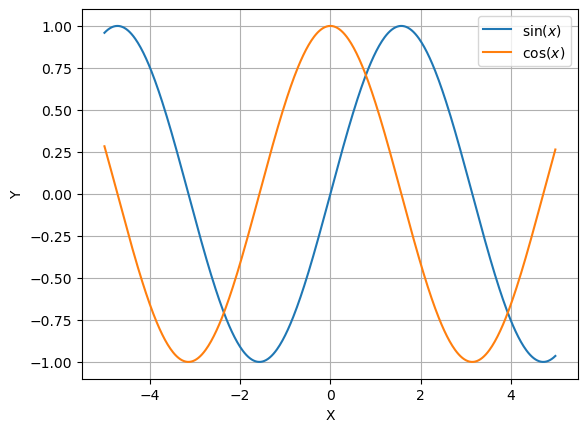

In [10]:
x = np.arange(-5, 5, .02)
plt.plot(x, np.sin(x), label=r'$\sin (x)$')
plt.plot(x, np.cos(x), label=r'$\cos (x)$')

#Plots
# ALWAYS use labels
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.legend()

plt.show()
# If you want, save the figure:
# plt.savefig('myFig.pdf')